# Exploración del corpus CIEMPIESS para reconocimiento de locutor



En este notebook se realiza una exploración inicial del corpus **CIEMPIESS**, con el objetivo de comprender su estructura, sus metadatos y sus características principales antes de utilizarlo en modelos de reconocimiento de locutor.

El propósito de esta etapa no es entrenar modelos, sino analizar si el corpus cuenta con las condiciones necesarias para ser utilizado en una tarea de **speaker recognition**, particularmente en un esquema de **speaker verification**, donde se busca determinar si dos grabaciones corresponden al mismo locutor.

---

### Relación con el proyecto general

Los modelos **x-vectors** y **ECAPA-TDNN** suelen utilizarse para extraer representaciones vectoriales de una señal de voz. Estas representaciones, llamadas **embeddings**, condensan información acústica asociada al locutor.

Para comparar ambos modelos de manera adecuada, primero es necesario conocer la base de datos que se utilizará. En particular, se requiere saber:

- cuántos locutores existen,
- cuántos audios hay por locutor,
- cuánto dura cada audio,
- si los audios tienen una frecuencia de muestreo adecuada,
- si existe suficiente información para formar pares de comparación,
- y si el corpus presenta limitaciones importantes.

Esta exploración permitirá tomar decisiones fundamentadas para las siguientes etapas del proyecto.

# 00. ¿Qué es CIEMPIESS?

CIEMPIESS significa Corpus de Investigación en Español de México del Posgrado de Ingeniería Eléctrica y Servicio Social. Es una familia de corpus de voz en español mexicano, creada principalmente para reconocimiento automático del habla —ASR—, no específicamente para speaker recognition. Aun así, varias versiones contienen speaker_id, género, audios segmentados y transcripciones, por lo que pueden adaptarse para experimentos de reconocimiento/verificación de locutor.

La versión original de CIEMPIESS fue diseñada para crear modelos acústicos de ASR y contiene alrededor de 17 horas de programas de radio con habla espontánea entre moderador e invitados, tomada de Radio-IUS de la UNAM. 

# 01. Importación de librerías

En esta sección se importan las librerías necesarias para realizar la exploración inicial del corpus.
El objetivo de esta sección es facilitar la reproducibilidad y permitir que cualquier persona identifique rápidamente las herramientas utilizadas.

Para garantizar la correcta ejecución del código es necesario contar con un entorno de procesamiento de señales optimizado. por lo que es necesario que se instalen las siguientes librerías:

In [ ]:
# pip install datasets torchaudio torch

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.9 MB ? eta -:--:--
   ---------------- ----------------------- 0.8/1.9 MB 5.6 MB/s eta 0:00:01
   -------------------------------------- - 1.8/1.9 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 3.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Importamos las librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carga de datasets desde Hugging Face
from datasets import load_dataset
from datasets import Audio
import soundfile as sf

# Reproducción de audio dentro de Jupyter Notebook
import IPython.display as ipd

# Configuración básica para visualizar mejor las tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

### Descripción de las librerías utilizadas

- `pandas`: permite construir y manipular tablas de datos. Será útil para crear una tabla de metadatos del corpus.
- `numpy`: permite realizar operaciones numéricas con arreglos, especialmente sobre las señales de audio.
- `matplotlib`: permite generar gráficas para analizar distribuciones, como duración de audios o número de audios por locutor.
- `datasets`: permite descargar y cargar datasets disponibles en Hugging Face.
- `soundfile`: Interfaz de bajo nivel para la lectura y escritura de archivos de audio. Proporciona la compatibilidad necesaria para manejar diversos formatos de archivo (WAV, FLAC) asegurando que no haya degradación en la calidad de la muestra.
- `IPython.display`: Módulo que permite la integración de un reproductor de audio interactivo directamente en el notebook, facilitando la validación auditiva inmediata de los segmentos analizados.
- `io`: Proporciona herramientas para la gestión de flujos de datos en memoria. Es esencial para procesar archivos de forma dinámica sin comprometer el almacenamiento físico con archivos temporales.
- `warnings`: Utilizada para el control de alertas del sistema. Su implementación permite filtrar mensajes de advertencia técnicos que no comprometen la validez del análisis, logrando un reporte final limpio y profesional.

# 2. Carga del corpus CIEMPIESS

En esta sección se carga el corpus **CIEMPIESS Light** utilizando la librería `datasets` de Hugging Face.

Se utiliza esta versión porque proporciona una forma práctica y reproducible de acceder al corpus. Además, contiene información relevante para reconocimiento de locutor, como identificadores de audio, identificadores de locutor, género y señales de audio.

In [3]:
ciempiess = load_dataset("ciempiess/ciempiess_light", split="train")

In [4]:
# Mostrar información general del dataset
ciempiess

Dataset({
    features: ['audio_id', 'audio', 'speaker_id', 'gender', 'duration', 'normalized_text'],
    num_rows: 16663
})

El objeto cargado corresponde a un dataset de Hugging Face. Este tipo de objeto permite acceder a cada registro del corpus de forma similar a una lista o tabla.

Cada registro representa un audio individual junto con sus metadatos asociados.

# 3. Inspección inicial de la estructura del dataset

Antes de realizar cualquier análisis estadístico, es necesario inspeccionar la estructura del corpus.

En esta sección se revisan:

- el número total de registros,
- los nombres de las columnas,
- la información disponible en un ejemplo individual,
- la estructura del campo de audio,
- la frecuencia de muestreo,
- el identificador de locutor,
- y el género del locutor.

Esta inspección permite entender cómo está organizado el dataset y qué variables pueden utilizarse en las siguientes etapas.

In [5]:
# Número total de registros
n_registros = len(ciempiess)

print(f"Número total de registros en el dataset: {n_registros}")

Número total de registros en el dataset: 16663


In [6]:
# Columnas disponibles en el dataset
ciempiess.column_names

['audio_id', 'audio', 'speaker_id', 'gender', 'duration', 'normalized_text']

Las columnas del dataset indican qué información está disponible para cada audio. Para tareas de reconocimiento de locutor, las columnas más importantes suelen ser aquellas relacionadas con:

- el identificador del audio,
- el identificador del locutor,
- el género,
- y la señal de audio.

# 4. Construcción de la tabla de metadatos

En esta sección se construye una tabla de metadatos a partir del corpus CIEMPIESS.

Aunque el dataset puede consultarse directamente desde el objeto cargado con Hugging Face, para realizar análisis exploratorio resulta más conveniente transformar la información relevante en un `DataFrame` de `pandas`.

Esta tabla será la base para los análisis posteriores de duración, distribución por locutor y distribución por género.

## 4.1 Extracción de metadatos de cada audio

Cada registro del corpus representa un archivo de audio junto con sus metadatos asociados.

Para construir la tabla, recorreremos todos los registros del dataset y extraeremos la información necesaria. En particular, para cada audio calcularemos su duración usando la relación:

$$
\text{duración} = \frac{\text{número de muestras}}{\text{frecuencia de muestreo}}
$$

donde:

- el número de muestras corresponde al tamaño del arreglo de audio,
- y la frecuencia de muestreo indica cuántas muestras se tienen por segundo.

Este cálculo es importante porque la duración de los audios influye directamente en la calidad de los embeddings que pueden extraerse posteriormente con modelos como x-vectors o ECAPA-TDNN.

In [7]:
# Evitar decodificación automática del audio con torchcodec
ciempiess = ciempiess.cast_column("audio", Audio(decode=False))

registros = []

for item in ciempiess:
    
    audio_info = item["audio"]
    
    audio_path = audio_info["path"]
    audio_bytes = audio_info["bytes"]
    
    # Caso 1: el dataset contiene el audio como bytes
    if audio_bytes is not None:
        info = sf.info(io.BytesIO(audio_bytes))
    
    # Caso 2: el dataset contiene una ruta local válida
    else:
        info = sf.info(audio_path)
    
    sampling_rate = info.samplerate
    num_samples = info.frames
    duration_sec = num_samples / sampling_rate
    
    registros.append({
        "audio_id": item["audio_id"],
        "speaker_id": item["speaker_id"],
        "gender": item["gender"],
        "audio_path": audio_path,
        "sampling_rate": sampling_rate,
        "num_samples": num_samples,
        "duration_sec": duration_sec
    })

df_meta = pd.DataFrame(registros)

df_meta.head()

,audio_id,speaker_id,gender,audio_path,sampling_rate,num_samples,duration_sec
0,CMPL_F_32_11ANG_00003,F_32,female,CMPL_F_32_11ANG_00003.flac,16000,52108,3.256750
1,CMPL_F_32_11ANG_00002,F_32,female,CMPL_F_32_11ANG_00002.flac,16000,17936,1.121000
2,CMPL_F_32_11ANG_00019,F_32,female,CMPL_F_32_11ANG_00019.flac,16000,37938,2.371125
3,CMPL_F_32_11ANG_00015,F_32,female,CMPL_F_32_11ANG_00015.flac,16000,28236,1.764750
4,CMPL_F_32_11ANG_00010,F_32,female,CMPL_F_32_11ANG_00010.flac,16000,43859,2.741188


### Nota sobre rutas de audio y decodificación

Al trabajar con datasets de audio desde Hugging Face, la columna `audio` puede comportarse de distintas formas dependiendo de cómo esté almacenado el corpus.

Cuando se usa `Audio(decode=True)`, el dataset intenta decodificar automáticamente la señal. En este entorno, esa decodificación generó un problema de compatibilidad con `torchcodec`.

Por esta razón, se utilizó `Audio(decode=False)`, lo cual permite acceder a la información subyacente del audio sin decodificarlo automáticamente. En este modo, Hugging Face puede devolver una ruta local al archivo o los bytes del archivo.

En este corpus, la ruta mostrada puede no ser una ruta absoluta en disco, por lo que se revisa si el audio está disponible como bytes. Si los bytes están disponibles, se puede obtener la duración usando `soundfile` a partir de un objeto `BytesIO`.

# 5. Estadísticas generales del corpus

Una vez construida la tabla de metadatos `df_meta`, el siguiente paso es obtener una descripción general del corpus.

Esta sección tiene como objetivo cuantificar las características principales de CIEMPIESS Light, tales como:

- número total de audios,
- número total de locutores,
- duración total del corpus,
- duración mínima, máxima, promedio y mediana de los audios,
- frecuencias de muestreo presentes,
- número de audios por género,
- y número de locutores por género.

Estas estadísticas permiten tener una primera visión global del corpus y ayudan a determinar si la base de datos es adecuada para tareas de reconocimiento de locutor.

### 5.1 Dimensiones generales del corpus

Primero se calcula el número total de audios disponibles en el corpus y el número de locutores distintos.

Estas cantidades son importantes porque, en reconocimiento de locutor, no solo importa tener muchos audios, sino también contar con suficientes locutores diferentes y suficientes grabaciones por locutor.

In [8]:
n_audios = len(df_meta)
n_locutores = df_meta["speaker_id"].nunique()

print(f"Número total de audios: {n_audios}")
print(f"Número total de locutores: {n_locutores}")

Número total de audios: 16663
Número total de locutores: 87


### 5.2 Duración total del corpus

La duración total del corpus permite conocer cuántas horas de audio están disponibles para el análisis.

Este valor es relevante porque los modelos de reconocimiento de locutor dependen de la cantidad y diversidad de información acústica disponible. Aunque en esta etapa todavía no se entrenan modelos, conocer la duración total permite evaluar la escala del corpus.

In [9]:
duracion_total_seg = df_meta["duration_sec"].sum()
duracion_total_min = duracion_total_seg / 60
duracion_total_horas = duracion_total_seg / 3600

print(f"Duración total en segundos: {duracion_total_seg:,.2f}")
print(f"Duración total en minutos: {duracion_total_min:,.2f}")
print(f"Duración total en horas: {duracion_total_horas:,.2f}")

Duración total en segundos: 66,326.41
Duración total en minutos: 1,105.44
Duración total en horas: 18.42


### 5.3 Estadísticas de duración por audio

A continuación se calculan estadísticas descriptivas de la duración de los audios.

La duración de cada grabación es una variable importante porque los embeddings de locutor se extraen a partir de información acústica contenida en la señal. Si un audio es demasiado corto, puede no contener suficiente información para representar adecuadamente al locutor.

Por esta razón, se analizan medidas como:

- duración mínima,
- primer cuartil,
- mediana,
- media,
- tercer cuartil,
- duración máxima,
- y desviación estándar.

In [10]:
# Resumen de duración en formato tabular
resumen_duracion = pd.DataFrame({
    "Métrica": [
        "Duración mínima",
        "Primer cuartil",
        "Mediana",
        "Media",
        "Tercer cuartil",
        "Duración máxima",
        "Desviación estándar"
    ],
    "Valor en segundos": [
        df_meta["duration_sec"].min(),
        df_meta["duration_sec"].quantile(0.25),
        df_meta["duration_sec"].median(),
        df_meta["duration_sec"].mean(),
        df_meta["duration_sec"].quantile(0.75),
        df_meta["duration_sec"].max(),
        df_meta["duration_sec"].std()
    ]
})

resumen_duracion

,Métrica,Valor en segundos
0,Duración mínima,0.428125
1,Primer cuartil,2.189375
2,Mediana,3.301000
3,Media,3.980460
4,Tercer cuartil,5.264687
5,Duración máxima,56.688625
6,Desviación estándar,2.447362


### 5.4 Revisión de la frecuencia de muestreo

La frecuencia de muestreo indica cuántas muestras por segundo contiene cada señal de audio.

En muchos modelos preentrenados de reconocimiento de locutor, como los disponibles en librerías especializadas, se suele trabajar con audios a **16 kHz**. Por ello, es importante verificar si todos los audios del corpus tienen la misma frecuencia de muestreo.

Si existieran audios con diferentes frecuencias de muestreo, sería necesario aplicar un proceso de remuestreo antes de extraer embeddings.

In [11]:
df_meta["sampling_rate"].value_counts()

sampling_rate
16000    16663
Name: count, dtype: int64

In [12]:
# Verificar si todos los audios tienen la misma frecuencia de muestreo
n_sampling_rates = df_meta["sampling_rate"].nunique()

if n_sampling_rates == 1:
    sr_unico = df_meta["sampling_rate"].iloc[0]
    print(f"Todos los audios tienen la misma frecuencia de muestreo: {sr_unico} Hz")
else:
    print(f"Existen {n_sampling_rates} frecuencias de muestreo distintas:")
    print(df_meta["sampling_rate"].value_counts())

Todos los audios tienen la misma frecuencia de muestreo: 16000 Hz


### 5.5 Resumen por género

En esta subsección se analiza la distribución del corpus por género.

Este análisis es importante porque un corpus desbalanceado puede influir en la evaluación de modelos de reconocimiento de locutor. Por ejemplo, si hay más audios o más locutores de un género que de otro, el desempeño global del sistema podría reflejar principalmente el comportamiento sobre el grupo mayoritario.

Aquí se calcularán:

- número de audios por género,
- número de locutores por género,
- duración total por género,
- y duración promedio por audio dentro de cada género.

In [13]:
resumen_genero = (
    df_meta
    .groupby("gender")
    .agg(
        n_audios=("audio_id", "count"),
        n_locutores=("speaker_id", "nunique"),
        duracion_total_seg=("duration_sec", "sum"),
        duracion_promedio_seg=("duration_sec", "mean"),
        duracion_mediana_seg=("duration_sec", "median")
    )
    .reset_index()
)

# Agregar duración en horas
resumen_genero["duracion_total_horas"] = resumen_genero["duracion_total_seg"] / 3600

resumen_genero

,gender,n_audios,n_locutores,duracion_total_seg,duracion_promedio_seg,duracion_mediana_seg,duracion_total_horas
0,female,4142,34,20663.673375,4.988815,4.573313,5.739909
1,male,12521,53,45662.734563,3.646892,3.060563,12.684093


# 6. Análisis de duración de los audios

En esta sección se analiza con mayor detalle la duración de los audios del corpus.

La duración de una grabación es una variable importante en reconocimiento de locutor, ya que los modelos necesitan suficiente información acústica para construir una representación estable del hablante.

En general, audios demasiado cortos pueden dificultar la extracción de embeddings robustos, mientras que audios muy largos pueden requerir estrategias adicionales de segmentación o procesamiento.

### 6.1 Histograma de duración

El histograma permite observar cómo se distribuyen las duraciones de los audios.

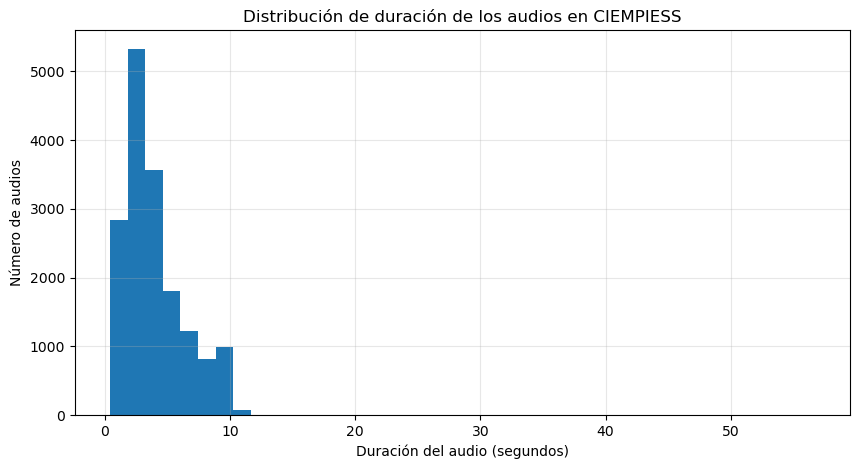

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df_meta["duration_sec"], bins=40)
plt.xlabel("Duración del audio (segundos)")
plt.ylabel("Número de audios")
plt.title("Distribución de duración de los audios en CIEMPIESS")
plt.grid(alpha=0.3)
plt.show()

### 6.2 Percentiles de duración

Los percentiles permiten describir la distribución de duración de manera más detallada.

Por ejemplo:

- el percentil 10 indica que el 10% de los audios tiene una duración menor o igual a ese valor,
- el percentil 50 corresponde a la mediana,
- el percentil 90 indica que el 90% de los audios tiene una duración menor o igual a ese valor.

Este análisis ayuda a seleccionar umbrales razonables para posibles filtros de duración.

In [15]:
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

tabla_percentiles = pd.DataFrame({
    "Percentil": [f"{int(p*100)}%" for p in percentiles],
    "Duración (segundos)": [df_meta["duration_sec"].quantile(p) for p in percentiles]
})

tabla_percentiles

,Percentil,Duración (segundos)
0,1%,0.854500
1,5%,1.214150
2,10%,1.497625
3,25%,2.189375
4,50%,3.301000
5,75%,5.264687
6,90%,7.894750
7,95%,9.257000
8,99%,10.114529


### 6.3 Porcentaje de audios por rango de duración

Además del número absoluto de audios por rango, es útil calcular el porcentaje que representa cada intervalo respecto al total del corpus.

Esto permite interpretar con mayor claridad qué tan frecuente es cada rango de duración.

In [16]:
bins = [0, 1, 2, 5, 10, 20, np.inf]
labels = [
    "0 a 1 s",
    "1 a 2 s",
    "2 a 5 s",
    "5 a 10 s",
    "10 a 20 s",
    "Más de 20 s"
]

df_meta["duration_range"] = pd.cut(
    df_meta["duration_sec"],
    bins=bins,
    labels=labels,
    right=False
)

conteo_rangos_duracion = (
    df_meta["duration_range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

conteo_rangos_duracion.columns = ["Rango de duración", "Número de audios"]

conteo_rangos_duracion["Porcentaje"] = (
    conteo_rangos_duracion["Número de audios"] / len(df_meta) * 100
)

conteo_rangos_duracion

,Rango de duración,Número de audios,Porcentaje
0,0 a 1 s,365,2.190482
1,1 a 2 s,3046,18.280022
2,2 a 5 s,8763,52.589570
3,5 a 10 s,4230,25.385585
4,10 a 20 s,256,1.536338
5,Más de 20 s,3,0.018004


### 6.4 Identificación de audios muy cortos

En reconocimiento de locutor, los audios demasiado cortos pueden ser problemáticos porque contienen poca información acústica del hablante.

Aunque no existe un único umbral universal, en una primera exploración puede ser útil revisar cuántos audios tienen una duración menor a ciertos valores, por ejemplo:

- 1 segundo,
- 2 segundos,
- 3 segundos.

Esta revisión ayuda a decidir si se debe aplicar un criterio preliminar de filtrado.

In [17]:
umbrales = [1, 2, 3]

for umbral in umbrales:
    n_cortos = (df_meta["duration_sec"] < umbral).sum()
    porcentaje = n_cortos / len(df_meta) * 100
    
    print(f"Audios con duración menor a {umbral} segundo(s): {n_cortos} ({porcentaje:.2f}%)")

Audios con duración menor a 1 segundo(s): 365 (2.19%)
Audios con duración menor a 2 segundo(s): 3411 (20.47%)
Audios con duración menor a 3 segundo(s): 7268 (43.62%)


### 6.5 Criterio preliminar de filtrado por duración

Después de analizar la distribución de duración, se puede proponer un criterio preliminar de filtrado.

Este criterio no se aplicará de forma definitiva hasta revisar también la distribución por locutor. Esto es importante porque eliminar audios cortos podría afectar de manera desigual a ciertos locutores.

Por ahora, se evalúa cuántos audios se conservarían si se aplicara un umbral mínimo de duración.

In [18]:
umbral_min_duracion = 2.0

df_meta_preliminar = df_meta[df_meta["duration_sec"] >= umbral_min_duracion].copy()

n_original = len(df_meta)
n_filtrado = len(df_meta_preliminar)
n_eliminados = n_original - n_filtrado

print(f"Umbral mínimo de duración: {umbral_min_duracion} segundos")
print(f"Audios originales: {n_original}")
print(f"Audios conservados: {n_filtrado}")
print(f"Audios eliminados: {n_eliminados}")
print(f"Porcentaje eliminado: {n_eliminados / n_original * 100:.2f}%")

Umbral mínimo de duración: 2.0 segundos
Audios originales: 16663
Audios conservados: 13252
Audios eliminados: 3411
Porcentaje eliminado: 20.47%


### 6.6 Comparación antes y después del filtro preliminar

Para evaluar el impacto del filtro de duración, se comparan algunas estadísticas antes y después de aplicar el umbral mínimo.

Este paso ayuda a entender si el filtro modifica de forma significativa la composición del corpus.

In [19]:
comparacion_filtro_duracion = pd.DataFrame({
    "Conjunto": ["Original", "Filtrado preliminar"],
    "Número de audios": [len(df_meta), len(df_meta_preliminar)],
    "Número de locutores": [
        df_meta["speaker_id"].nunique(),
        df_meta_preliminar["speaker_id"].nunique()
    ],
    "Duración total horas": [
        df_meta["duration_sec"].sum() / 3600,
        df_meta_preliminar["duration_sec"].sum() / 3600
    ],
    "Duración promedio segundos": [
        df_meta["duration_sec"].mean(),
        df_meta_preliminar["duration_sec"].mean()
    ],
    "Duración mediana segundos": [
        df_meta["duration_sec"].median(),
        df_meta_preliminar["duration_sec"].median()
    ]
})

comparacion_filtro_duracion

,Conjunto,Número de audios,Número de locutores,Duración total horas,Duración promedio segundos,Duración mediana segundos
0,Original,16663,87,18.424002,3.980460,3.301000
1,Filtrado preliminar,13252,87,17.030359,4.626418,3.842938


# 7. Análisis por locutor

En esta sección se analiza la distribución del corpus a nivel de locutor.

Para tareas de reconocimiento de locutor, esta parte es fundamental porque cada hablante debe contar con suficientes grabaciones para que sea posible construir experimentos de identificación o verificación.

En particular, para una tarea de **speaker verification**, se necesitan audios del mismo locutor para formar **pares positivos** y audios de diferentes locutores para formar **pares negativos**.



### 7.1 Construcción de tabla resumen por locutor

Primero se construye una tabla agregada por `speaker_id`.

Esta tabla resume la información disponible para cada locutor, incluyendo:

- número total de audios,
- duración total en segundos,
- duración total en minutos,
- duración promedio por audio,
- duración mediana por audio,
- duración mínima,
- duración máxima,
- y género asociado al locutor.

Esta tabla permite identificar si todos los locutores tienen una cantidad similar de información o si existen desbalances importantes.

In [20]:
resumen_locutor = (
    df_meta
    .groupby("speaker_id")
    .agg(
        gender=("gender", "first"),
        n_audios=("audio_id", "count"),
        duracion_total_seg=("duration_sec", "sum"),
        duracion_promedio_seg=("duration_sec", "mean"),
        duracion_mediana_seg=("duration_sec", "median"),
        duracion_min_seg=("duration_sec", "min"),
        duracion_max_seg=("duration_sec", "max")
    )
    .reset_index()
)

# Agregar duración total en minutos
resumen_locutor["duracion_total_min"] = resumen_locutor["duracion_total_seg"] / 60

# Ordenar por número de audios
resumen_locutor = resumen_locutor.sort_values("n_audios", ascending=False)

resumen_locutor.head()

,speaker_id,gender,n_audios,duracion_total_seg,duracion_promedio_seg,duracion_mediana_seg,duracion_min_seg,duracion_max_seg,duracion_total_min
34,M_01,male,1751,4938.070062,2.820143,2.522875,0.446313,10.254250,82.301168
35,M_02,male,965,2313.013812,2.396906,2.239438,0.535188,8.017938,38.550230
0,F_01,female,931,3900.497438,4.189578,3.572938,0.439500,10.718000,65.008291
36,M_03,male,868,5482.957688,6.316772,6.525563,0.764938,56.688625,91.382628
37,M_04,male,640,1930.611437,3.016580,2.737125,0.428125,8.497250,32.176857


### 7.2 Locutores con mayor número de audios

A continuación se muestran los locutores con más grabaciones dentro del corpus.

Estos locutores tienen más información disponible y podrían aportar una mayor cantidad de pares positivos para tareas de verificación de locutor.

Sin embargo, también es importante revisar si algunos locutores dominan demasiado el corpus, ya que esto podría generar desbalance en el análisis.

In [21]:
locutores_mas_audios = resumen_locutor.head(10)

locutores_mas_audios

,speaker_id,gender,n_audios,duracion_total_seg,duracion_promedio_seg,duracion_mediana_seg,duracion_min_seg,duracion_max_seg,duracion_total_min
34,M_01,male,1751,4938.070062,2.820143,2.522875,0.446313,10.254250,82.301168
35,M_02,male,965,2313.013812,2.396906,2.239438,0.535188,8.017938,38.550230
0,F_01,female,931,3900.497438,4.189578,3.572938,0.439500,10.718000,65.008291
36,M_03,male,868,5482.957688,6.316772,6.525563,0.764938,56.688625,91.382628
37,M_04,male,640,1930.611437,3.016580,2.737125,0.428125,8.497250,32.176857
38,M_05,male,547,1261.839937,2.306837,2.132875,0.615187,5.587625,21.030666
39,M_06,male,496,1145.366812,2.309207,2.189844,0.678250,4.841375,19.089447
40,M_07,male,474,2202.033562,4.645640,4.027000,0.987625,11.073438,36.700559
41,M_08,male,471,1308.085500,2.777252,2.779125,0.871625,4.928187,21.801425
1,F_02,female,458,2950.414563,6.441953,6.751250,1.133875,10.446500,49.173576


### 7.3 Locutores con menor número de audios

También es necesario identificar los locutores con menos grabaciones.

En reconocimiento de locutor, los hablantes con muy pocos audios pueden representar un problema porque limitan la construcción de pares positivos o la separación entre audios de inscripción y prueba.

Por ejemplo, si un locutor tiene solo un audio, no es posible construir un par positivo usando únicamente sus grabaciones.

In [22]:
locutores_menos_audios = resumen_locutor.sort_values("n_audios", ascending=True).head(10)

locutores_menos_audios

,speaker_id,gender,n_audios,duracion_total_seg,duracion_promedio_seg,duracion_mediana_seg,duracion_min_seg,duracion_max_seg,duracion_total_min
33,F_34,female,16,48.488937,3.030559,2.758969,1.901687,4.847937,0.808149
32,F_33,female,21,56.122875,2.672518,2.789813,0.867062,4.586875,0.935381
31,F_32,female,22,45.622250,2.073739,2.036594,0.660813,3.256750,0.760371
86,M_53,male,26,111.877687,4.302988,3.864156,1.650813,9.125813,1.864628
85,M_52,male,26,112.394312,4.322858,4.060125,2.608312,6.889938,1.873239
84,M_51,male,27,83.601062,3.096336,3.050125,1.485437,4.832687,1.393351
30,F_31,female,28,136.096812,4.860600,4.522250,1.417250,8.432875,2.268280
83,M_50,male,29,156.238563,5.387537,5.363437,1.952687,8.694937,2.603976
82,M_49,male,29,88.386687,3.047817,2.930625,1.932125,4.123687,1.473111
29,F_30,female,31,143.529937,4.629998,4.692812,1.352500,8.732812,2.392166


### 7.4 Locutores con menor duración total

Además del número de audios, es importante revisar cuánta duración total de audio tiene cada locutor. Dos locutores podrían tener el mismo número de audios, pero duraciones totales diferentes si sus grabaciones son más cortas o más largas. La duración total por locutor permite evaluar cuánta información acústica está disponible para cada hablante.

A continuación se muestran los locutores con menor cantidad total de audio. Estos casos son relevantes porque podrían tener poca información acústica para etapas posteriores de evaluación.

In [23]:
locutores_menor_duracion = (
    resumen_locutor
    .sort_values("duracion_total_min", ascending=True)
    .head(10)
)

locutores_menor_duracion

,speaker_id,gender,n_audios,duracion_total_seg,duracion_promedio_seg,duracion_mediana_seg,duracion_min_seg,duracion_max_seg,duracion_total_min
31,F_32,female,22,45.622250,2.073739,2.036594,0.660813,3.256750,0.760371
33,F_34,female,16,48.488937,3.030559,2.758969,1.901687,4.847937,0.808149
32,F_33,female,21,56.122875,2.672518,2.789813,0.867062,4.586875,0.935381
84,M_51,male,27,83.601062,3.096336,3.050125,1.485437,4.832687,1.393351
82,M_49,male,29,88.386687,3.047817,2.930625,1.932125,4.123687,1.473111
81,M_48,male,34,110.519125,3.250563,3.553094,1.243375,5.692750,1.841985
24,F_25,female,49,110.704375,2.259273,2.071625,0.750313,5.304312,1.845073
86,M_53,male,26,111.877687,4.302988,3.864156,1.650813,9.125813,1.864628
85,M_52,male,26,112.394312,4.322858,4.060125,2.608312,6.889938,1.873239
26,F_27,female,41,134.944063,3.291319,3.433562,0.913062,6.619813,2.249068


### 7.5 Revisión de locutores con pocos audios

Para tareas de verificación de locutor, cada locutor necesita al menos dos audios para formar un par positivo. Sin embargo, en la práctica es recomendable contar con más de dos grabaciones por locutor, ya que normalmente se requiere separar audios para inscripción, prueba y evaluación.

En esta subsección se revisa cuántos locutores tienen menos de ciertos umbrales de audios.

In [24]:
umbrales_audios = [2, 5, 10, 20]

for umbral in umbrales_audios:
    n_locutores_bajo_umbral = (resumen_locutor["n_audios"] < umbral).sum()
    porcentaje = n_locutores_bajo_umbral / len(resumen_locutor) * 100
    
    print(
        f"Locutores con menos de {umbral} audios: "
        f"{n_locutores_bajo_umbral} ({porcentaje:.2f}%)"
    )

Locutores con menos de 2 audios: 0 (0.00%)
Locutores con menos de 5 audios: 0 (0.00%)
Locutores con menos de 10 audios: 0 (0.00%)
Locutores con menos de 20 audios: 1 (1.15%)


### 7.6 Impacto del filtro preliminar por duración en los locutores

En la sección anterior se propuso un filtro preliminar para conservar audios con duración mayor o igual a 2 segundos.

Sin embargo, antes de adoptar este filtro, es necesario revisar cómo afecta a cada locutor. Un filtro global puede parecer razonable, pero podría eliminar demasiadas grabaciones de ciertos hablantes.

En esta subsección se compara el número de audios por locutor antes y después del filtro preliminar.

In [25]:
# Resumen por locutor antes del filtro
resumen_original_locutor = (
    df_meta
    .groupby("speaker_id")
    .agg(
        n_audios_original=("audio_id", "count"),
        duracion_total_original_seg=("duration_sec", "sum")
    )
    .reset_index()
)

# Resumen por locutor después del filtro preliminar
resumen_filtrado_locutor = (
    df_meta_preliminar
    .groupby("speaker_id")
    .agg(
        n_audios_filtrado=("audio_id", "count"),
        duracion_total_filtrada_seg=("duration_sec", "sum")
    )
    .reset_index()
)

# Unir ambos resúmenes
impacto_filtro_locutor = resumen_original_locutor.merge(
    resumen_filtrado_locutor,
    on="speaker_id",
    how="left"
)

# Si algún locutor perdió todos sus audios, tendrá valores faltantes
impacto_filtro_locutor["n_audios_filtrado"] = impacto_filtro_locutor["n_audios_filtrado"].fillna(0).astype(int)
impacto_filtro_locutor["duracion_total_filtrada_seg"] = impacto_filtro_locutor["duracion_total_filtrada_seg"].fillna(0)

# Calcular audios eliminados
impacto_filtro_locutor["audios_eliminados"] = (
    impacto_filtro_locutor["n_audios_original"] - impacto_filtro_locutor["n_audios_filtrado"]
)

impacto_filtro_locutor["porcentaje_audios_eliminados"] = (
    impacto_filtro_locutor["audios_eliminados"] / impacto_filtro_locutor["n_audios_original"] * 100
)

impacto_filtro_locutor.sort_values("porcentaje_audios_eliminados", ascending=False).head(10)

,speaker_id,n_audios_original,duracion_total_original_seg,n_audios_filtrado,duracion_total_filtrada_seg,audios_eliminados,porcentaje_audios_eliminados
71,M_38,76,146.267687,28,80.375938,48,63.157895
44,M_11,299,607.912563,132,370.188375,167,55.852843
12,F_13,92,192.215250,46,126.036500,46,50.000000
24,F_25,49,110.704375,26,79.823500,23,46.938776
31,F_32,22,45.622250,12,31.430688,10,45.454545
10,F_11,102,235.953375,56,169.522437,46,45.098039
38,M_05,547,1261.839937,301,908.922187,246,44.972578
14,F_15,88,199.394250,49,142.674563,39,44.318182
39,M_06,496,1145.366812,281,829.404063,215,43.346774
35,M_02,965,2313.013812,572,1746.784312,393,40.725389


### 7.7 Locutores afectados críticamente por el filtro

Un caso especialmente importante ocurre cuando un locutor pierde todos sus audios después de aplicar el filtro. Si esto sucede, ese locutor ya no podría utilizarse en el análisis posterior.

Por esta razón, se identifica cuántos locutores quedarían sin audios al aplicar el filtro preliminar.

In [26]:
locutores_sin_audios_filtrados = impacto_filtro_locutor[
    impacto_filtro_locutor["n_audios_filtrado"] == 0
]

print(f"Locutores que perderían todos sus audios: {len(locutores_sin_audios_filtrados)}")

locutores_sin_audios_filtrados

Locutores que perderían todos sus audios: 0


,speaker_id,n_audios_original,duracion_total_original_seg,n_audios_filtrado,duracion_total_filtrada_seg,audios_eliminados,porcentaje_audios_eliminados


### 7.8 Locutores con pocos audios después del filtro

Además de revisar si algún locutor pierde todos sus audios, también es importante identificar cuántos locutores quedarían con muy pocas grabaciones después del filtrado.

Esto permite evaluar si el filtro propuesto sigue siendo adecuado para una tarea de verificación de locutor.

In [27]:
umbrales_audios = [2, 5, 10, 20]

for umbral in umbrales_audios:
    n_locutores_bajo_umbral = (impacto_filtro_locutor["n_audios_filtrado"] < umbral).sum()
    porcentaje = n_locutores_bajo_umbral / len(impacto_filtro_locutor) * 100
    
    print(
        f"Después del filtro, locutores con menos de {umbral} audios: "
        f"{n_locutores_bajo_umbral} ({porcentaje:.2f}%)"
    )

Después del filtro, locutores con menos de 2 audios: 0 (0.00%)
Después del filtro, locutores con menos de 5 audios: 0 (0.00%)
Después del filtro, locutores con menos de 10 audios: 0 (0.00%)
Después del filtro, locutores con menos de 20 audios: 3 (3.45%)


# 8. Análisis por género

En esta sección se analiza la distribución del corpus respecto al género de los locutores.

Este análisis es relevante porque los modelos de reconocimiento de locutor pueden verse afectados por desbalances en los datos. Si un corpus contiene muchos más audios, más duración total o más locutores de un grupo que de otro, la evaluación global podría reflejar principalmente el comportamiento del modelo sobre el grupo mayoritario.

En esta sección se estudiará:

- número de audios por género,
- número de locutores por género,
- duración total de audio por género,
- duración promedio por audio,
- duración promedio por locutor,
- distribución de duración de audios por género,
- y posibles diferencias entre grupos.

### 8.1 Conteo de audios por género

Primero se calcula cuántos audios existen para cada género registrado en el corpus.

Este conteo permite observar si la base contiene una cantidad similar de grabaciones entre grupos o si existe un desbalance importante.

In [28]:
conteo_audios_genero = (
    df_meta["gender"]
    .value_counts()
    .reset_index()
)

conteo_audios_genero.columns = ["gender", "n_audios"]

conteo_audios_genero["porcentaje"] = (
    conteo_audios_genero["n_audios"] / len(df_meta) * 100
)

conteo_audios_genero

,gender,n_audios,porcentaje
0,male,12521,75.142531
1,female,4142,24.857469


### 8.2 Conteo de locutores por género

En reconocimiento de locutor, no basta con revisar cuántos audios hay por género. También es necesario conocer cuántos locutores distintos existen en cada grupo.

Un corpus podría tener muchos audios de un género, pero concentrados en pocos locutores. Por ello, esta subsección calcula el número de hablantes únicos por género.

In [29]:
conteo_locutores_genero = (
    df_meta
    .groupby("gender")["speaker_id"]
    .nunique()
    .reset_index()
)

conteo_locutores_genero.columns = ["gender", "n_locutores"]

conteo_locutores_genero["porcentaje"] = (
    conteo_locutores_genero["n_locutores"] / df_meta["speaker_id"].nunique() * 100
)

conteo_locutores_genero

,gender,n_locutores,porcentaje
0,female,34,39.08046
1,male,53,60.91954


In [30]:

# Resumen completo por género

resumen_genero_completo = (
    df_meta
    .groupby("gender")
    .agg(
        n_audios=("audio_id", "count"),
        n_locutores=("speaker_id", "nunique"),
        duracion_total_seg=("duration_sec", "sum"),
        duracion_promedio_audio_seg=("duration_sec", "mean"),
        duracion_mediana_audio_seg=("duration_sec", "median"),
        duracion_min_audio_seg=("duration_sec", "min"),
        duracion_max_audio_seg=("duration_sec", "max")
    )
    .reset_index()
)

resumen_genero_completo["duracion_total_horas"] = (
    resumen_genero_completo["duracion_total_seg"] / 3600
)

resumen_genero_completo["audios_promedio_por_locutor"] = (
    resumen_genero_completo["n_audios"] / resumen_genero_completo["n_locutores"]
)

resumen_genero_completo

,gender,n_audios,n_locutores,duracion_total_seg,duracion_promedio_audio_seg,duracion_mediana_audio_seg,duracion_min_audio_seg,duracion_max_audio_seg,duracion_total_horas,audios_promedio_por_locutor
0,female,4142,34,20663.673375,4.988815,4.573313,0.439500,13.573625,5.739909,121.823529
1,male,12521,53,45662.734563,3.646892,3.060563,0.428125,56.688625,12.684093,236.245283


### 8.3 Duración total por género

La duración total permite comparar cuánta información acústica acumulada existe para cada género.

Este análisis es importante porque un grupo podría tener menos locutores, pero audios más largos, o más locutores con audios más cortos.

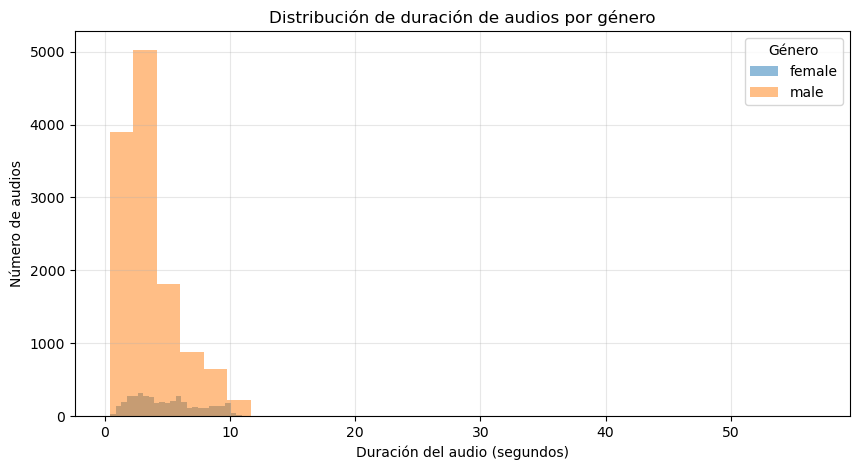

In [31]:

generos = df_meta["gender"].dropna().unique()

datos_por_genero = [
    df_meta[df_meta["gender"] == genero]["duration_sec"]
    for genero in generos
]

plt.figure(figsize=(10, 5))

for genero in generos:
    duraciones = df_meta[df_meta["gender"] == genero]["duration_sec"]
    plt.hist(duraciones, bins=30, alpha=0.5, label=str(genero))

plt.xlabel("Duración del audio (segundos)")
plt.ylabel("Número de audios")
plt.title("Distribución de duración de audios por género")
plt.legend(title="Género")
plt.grid(alpha=0.3)
plt.show()

### 8.4 Impacto del filtro preliminar por género

En secciones anteriores se propuso un filtro preliminar por duración, conservando audios con duración mayor o igual a 2 segundos.

Aquí se analiza si ese filtro afecta de forma diferente a cada género. Esto es importante porque un filtro aparentemente neutral podría eliminar más registros de un grupo que de otro.

In [32]:
resumen_genero_original = (
    df_meta
    .groupby("gender")
    .agg(
        n_audios_original=("audio_id", "count"),
        n_locutores_original=("speaker_id", "nunique"),
        duracion_total_original_seg=("duration_sec", "sum")
    )
    .reset_index()
)

resumen_genero_filtrado = (
    df_meta_preliminar
    .groupby("gender")
    .agg(
        n_audios_filtrado=("audio_id", "count"),
        n_locutores_filtrado=("speaker_id", "nunique"),
        duracion_total_filtrada_seg=("duration_sec", "sum")
    )
    .reset_index()
)

impacto_filtro_genero = resumen_genero_original.merge(
    resumen_genero_filtrado,
    on="gender",
    how="left"
)

impacto_filtro_genero["n_audios_filtrado"] = (
    impacto_filtro_genero["n_audios_filtrado"].fillna(0).astype(int)
)

impacto_filtro_genero["n_locutores_filtrado"] = (
    impacto_filtro_genero["n_locutores_filtrado"].fillna(0).astype(int)
)

impacto_filtro_genero["duracion_total_filtrada_seg"] = (
    impacto_filtro_genero["duracion_total_filtrada_seg"].fillna(0)
)

impacto_filtro_genero["audios_eliminados"] = (
    impacto_filtro_genero["n_audios_original"] 
    - impacto_filtro_genero["n_audios_filtrado"]
)

impacto_filtro_genero["porcentaje_audios_eliminados"] = (
    impacto_filtro_genero["audios_eliminados"] 
    / impacto_filtro_genero["n_audios_original"] * 100
)

impacto_filtro_genero

,gender,n_audios_original,n_locutores_original,duracion_total_original_seg,n_audios_filtrado,n_locutores_filtrado,duracion_total_filtrada_seg,audios_eliminados,porcentaje_audios_eliminados
0,female,4142,34,20663.673375,3642,34,19939.034312,500,12.071463
1,male,12521,53,45662.734563,9610,53,41370.259125,2911,23.248942


# 9. Revisión de ejemplos de audio

En esta sección se realiza una revisión cualitativa de algunos audios del corpus CIEMPIESS.

Hasta este punto, el análisis se ha centrado principalmente en metadatos: número de audios, duración, locutores y género. Sin embargo, para un proyecto de reconocimiento de locutor también es importante inspeccionar directamente algunas señales de audio.

La revisión cualitativa permite observar aspectos como:

- calidad general de la grabación,
- presencia de ruido,
- silencios al inicio o al final,
- variaciones de volumen,
- cortes abruptos,
- duración perceptual del audio,
- claridad de la voz,
- y posibles diferencias entre locutores.

Esta sección no sustituye al análisis estadístico, pero ayuda a comprender mejor el tipo de datos con los que trabajarán los modelos x-vectors y ECAPA-TDNN.

### 9.1 Selección de ejemplos de audio

Primero se seleccionan algunos registros del corpus para revisarlos de forma individual.

Se recomienda elegir ejemplos variados, por ejemplo:

- un audio corto,
- un audio de duración media,
- un audio largo,
- audios de diferentes locutores,
- y audios de distintos géneros.

Esto permite obtener una primera impresión más completa del corpus.

In [33]:
# Audio más corto
audio_corto = df_meta.sort_values("duration_sec").iloc[0]

# Audio de duración cercana a la mediana
duracion_mediana = df_meta["duration_sec"].median()
audio_mediano = df_meta.iloc[
    (df_meta["duration_sec"] - duracion_mediana).abs().argsort().iloc[0]
]

# Audio más largo
audio_largo = df_meta.sort_values("duration_sec", ascending=False).iloc[0]

ejemplos_audio = pd.DataFrame([
    audio_corto,
    audio_mediano,
    audio_largo
])

ejemplos_audio

,audio_id,speaker_id,gender,audio_path,sampling_rate,num_samples,duration_sec,duration_range
11779,CMPL_M_04_02ANG_00203,M_04,male,CMPL_M_04_02ANG_00203.flac,16000,6850,0.428125,0 a 1 s
7043,CMPL_M_03_01ANG_00069,M_03,male,CMPL_M_03_01ANG_00069.flac,16000,52816,3.301000,2 a 5 s
6717,CMPL_M_03_01ANG_00152,M_03,male,CMPL_M_03_01ANG_00152.flac,16000,907018,56.688625,Más de 20 s


Para reproducir o visualizar un audio, necesitamos recuperar la señal correspondiente dentro del dataset original.

Como previamente se trabajó con una tabla de metadatos, en esta subsección se define una función auxiliar que permite buscar un audio usando su identificador `audio_id`.

Esta función será útil para evitar repetir código cada vez que se quiera inspeccionar un ejemplo.

In [34]:
def obtener_item_por_audio_id(dataset, audio_id):
    """
    Busca un registro dentro del dataset a partir de su audio_id.
    
    Parámetros
    ----------
    dataset : datasets.Dataset
        Dataset de Hugging Face que contiene los audios.
        
    audio_id : str
        Identificador del audio que se desea buscar.
        
    Retorna
    -------
    dict
        Registro del dataset correspondiente al audio_id.
    """
    
    for item in dataset:
        if item["audio_id"] == audio_id:
            return item
    
    raise ValueError(f"No se encontró el audio_id: {audio_id}")

En este entorno se observaron problemas al intentar decodificar automáticamente los audios con la columna `audio` de Hugging Face. Para evitar depender de la decodificación automática, se trabajará con la columna de audio en modo `decode=False`.

Cuando el archivo de audio esté disponible como bytes, se leerá la señal utilizando `soundfile` y `io.BytesIO`.

Esta estrategia permite inspeccionar ejemplos de audio sin depender directamente de `torchcodec`.

In [35]:
from datasets import Audio
import soundfile as sf
import io

# Aseguramos que la columna audio esté sin decodificación automática
ciempiess_no_decode = ciempiess.cast_column("audio", Audio(decode=False))

def leer_audio_desde_item(item):
    """
    Lee la señal de audio de un registro del dataset.
    
    Esta función intenta leer el audio desde bytes cuando están disponibles.
    Si no hay bytes, intenta usar la ruta almacenada en el campo audio["path"].
    
    Parámetros
    ----------
    item : dict
        Registro individual del dataset.
        
    Retorna
    -------
    senal : np.ndarray
        Arreglo numérico con la señal de audio.
        
    sampling_rate : int
        Frecuencia de muestreo del audio.
    """
    
    audio_info = item["audio"]
    audio_bytes = audio_info["bytes"]
    audio_path = audio_info["path"]
    
    if audio_bytes is not None:
        senal, sampling_rate = sf.read(io.BytesIO(audio_bytes))
    else:
        senal, sampling_rate = sf.read(audio_path)
    
    return senal, sampling_rate

### 9.2 Inspección de audio corto, medio y largo

Para facilitar la revisión de múltiples ejemplos, se define una función que recibe un `audio_id`, recupera el audio correspondiente, muestra sus metadatos, reproduce la señal y grafica su forma de onda.

Esta función será útil para inspeccionar diferentes casos sin repetir código.



In [36]:
def inspeccionar_audio(dataset, audio_id):
    """
    Reproduce y visualiza un audio del corpus a partir de su audio_id.
    
    Parámetros
    ----------
    dataset : datasets.Dataset
        Dataset de Hugging Face con la columna audio en modo decode=False.
        
    audio_id : str
        Identificador del audio que se desea inspeccionar.
    """
    
    item = obtener_item_por_audio_id(dataset, audio_id)
    senal, sr = leer_audio_desde_item(item)
    
    duracion = len(senal) / sr
    tiempo = np.arange(len(senal)) / sr
    
    print("Información del audio")
    print("---------------------")
    print(f"Audio ID: {item['audio_id']}")
    print(f"Speaker ID: {item['speaker_id']}")
    print(f"Género: {item['gender']}")
    print(f"Frecuencia de muestreo: {sr} Hz")
    print(f"Número de muestras: {len(senal)}")
    print(f"Duración: {duracion:.2f} segundos")
    
    display(ipd.Audio(senal, rate=sr))
    
    plt.figure(figsize=(12, 4))
    plt.plot(tiempo, senal)
    plt.xlabel("Tiempo (segundos)")
    plt.ylabel("Amplitud")
    plt.title(f"Forma de onda del audio {item['audio_id']}")
    plt.grid(alpha=0.3)
    plt.show()

A continuación se inspeccionan tres ejemplos representativos:

- el audio más corto,
- un audio cercano a la duración mediana,
- y el audio más largo.

Esto permite comparar cómo cambia la señal en función de la duración.

Información del audio
---------------------
Audio ID: CMPL_M_04_02ANG_00203
Speaker ID: M_04
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 6850
Duración: 0.43 segundos


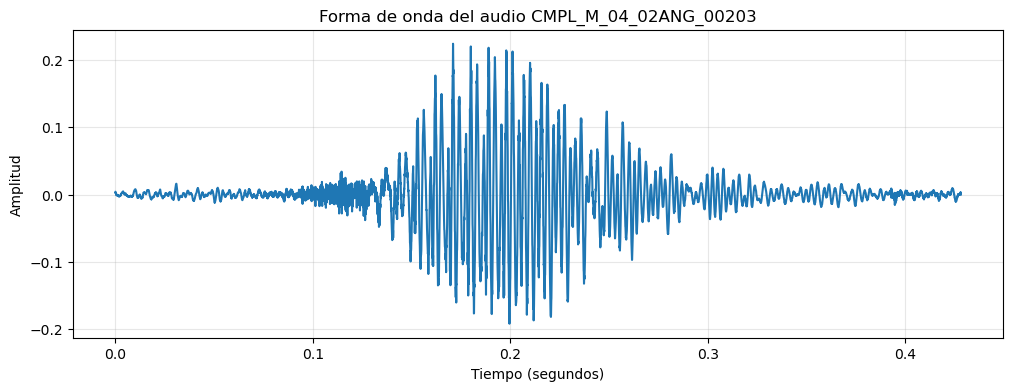

In [37]:
# Audio más corto
inspeccionar_audio(ciempiess_no_decode, audio_corto["audio_id"])

Información del audio
---------------------
Audio ID: CMPL_M_03_01ANG_00069
Speaker ID: M_03
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 52816
Duración: 3.30 segundos


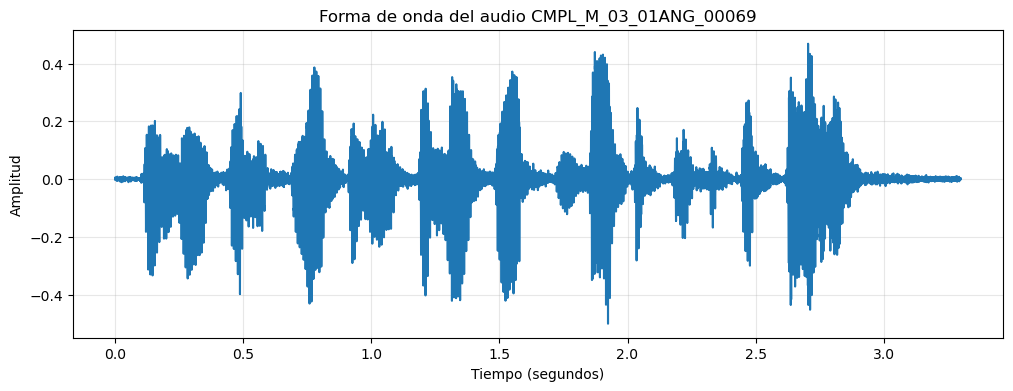

In [38]:
# Audio de duración mediana
inspeccionar_audio(ciempiess_no_decode, audio_mediano["audio_id"])

Información del audio
---------------------
Audio ID: CMPL_M_03_01ANG_00152
Speaker ID: M_03
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 907018
Duración: 56.69 segundos


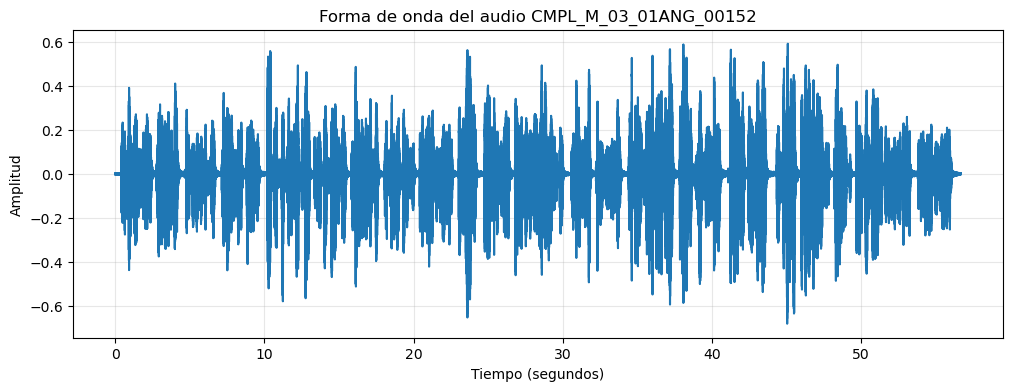

In [39]:
# Audio más largo
inspeccionar_audio(ciempiess_no_decode, audio_largo["audio_id"])

### 9.3 Selección e inspección de ejemplos por género

Además de revisar audios por duración, es útil inspeccionar ejemplos de diferentes géneros.

Esto permite observar si existen diferencias evidentes en calidad, duración o características generales de las grabaciones entre grupos.

In [40]:
ejemplos_por_genero = (
    df_meta
    .sort_values("duration_sec")
    .groupby("gender")
    .apply(lambda x: x.iloc[len(x) // 2])
    .reset_index(drop=True)
)

ejemplos_por_genero

,audio_id,speaker_id,gender,audio_path,sampling_rate,num_samples,duration_sec,duration_range
0,CMPL_F_15_06ANG_00030,F_15,female,CMPL_F_15_06ANG_00030.flac,16000,73189,4.574312,2 a 5 s
1,CMPL_M_10_09ANG_00326,M_10,male,CMPL_M_10_09ANG_00326.flac,16000,48969,3.060563,2 a 5 s


Se reproducen y visualizan ejemplos representativos de cada género registrado en el corpus.

Ejemplo del género: female
Información del audio
---------------------
Audio ID: CMPL_F_15_06ANG_00030
Speaker ID: F_15
Género: female
Frecuencia de muestreo: 16000 Hz
Número de muestras: 73189
Duración: 4.57 segundos


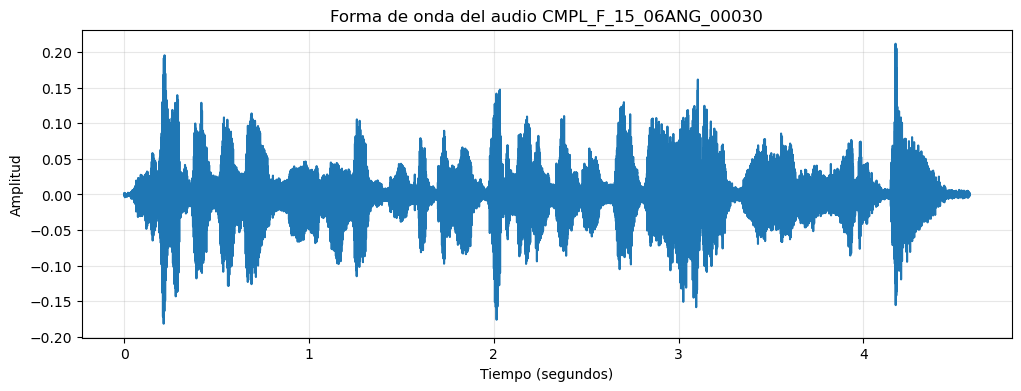

Ejemplo del género: male
Información del audio
---------------------
Audio ID: CMPL_M_10_09ANG_00326
Speaker ID: M_10
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 48969
Duración: 3.06 segundos


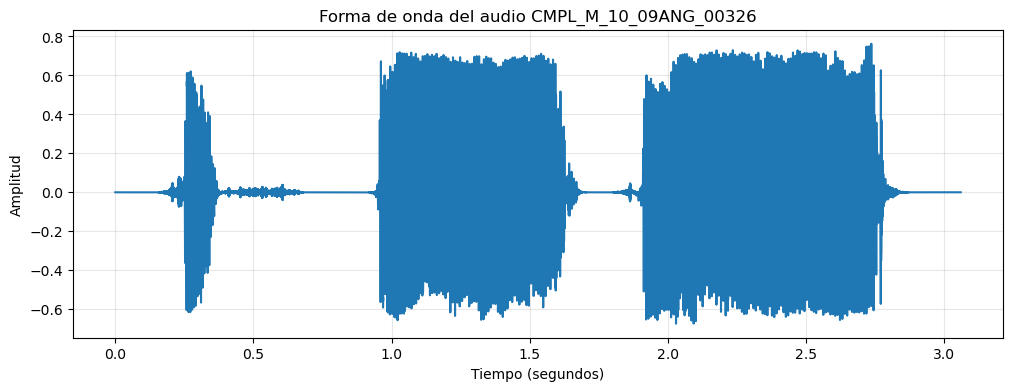

In [41]:
for _, row in ejemplos_por_genero.iterrows():
    print("=" * 80)
    print(f"Ejemplo del género: {row['gender']}")
    inspeccionar_audio(ciempiess_no_decode, row["audio_id"])

### 9.4 Selección e inspección de ejemplos de un mismo locutor

Para reconocimiento de locutor, es útil escuchar varios audios de una misma persona.Esto permite observar si los audios de un mismo hablante presentan consistencia acústica o si existen variaciones importantes en volumen, ruido, canal o duración.

En esta subsección se selecciona un locutor con varios audios disponibles.

In [42]:

# Elegimos el locutor con mayor número de audios
speaker_ejemplo = resumen_locutor.sort_values("n_audios", ascending=False).iloc[0]["speaker_id"]

audios_mismo_locutor = (
    df_meta[df_meta["speaker_id"] == speaker_ejemplo]
    .sort_values("duration_sec")
    .head(3)
)

print(f"Locutor seleccionado: {speaker_ejemplo}")
audios_mismo_locutor

Locutor seleccionado: M_01


,audio_id,speaker_id,gender,audio_path,sampling_rate,num_samples,duration_sec,duration_range
13909,CMPL_M_01_10ANG_01023,M_01,male,CMPL_M_01_10ANG_01023.flac,16000,7141,0.446313,0 a 1 s
13774,CMPL_M_01_10ANG_01117,M_01,male,CMPL_M_01_10ANG_01117.flac,16000,8139,0.508687,0 a 1 s
14010,CMPL_M_01_04ANG_00591,M_01,male,CMPL_M_01_04ANG_00591.flac,16000,8706,0.544125,0 a 1 s


A continuación se reproducen varios audios pertenecientes al mismo locutor.

Este análisis ayuda a familiarizarse con la variabilidad intra-locutor, es decir, las diferencias que pueden existir entre grabaciones de una misma persona.

Audio del locutor: M_01
Información del audio
---------------------
Audio ID: CMPL_M_01_10ANG_01023
Speaker ID: M_01
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 7141
Duración: 0.45 segundos


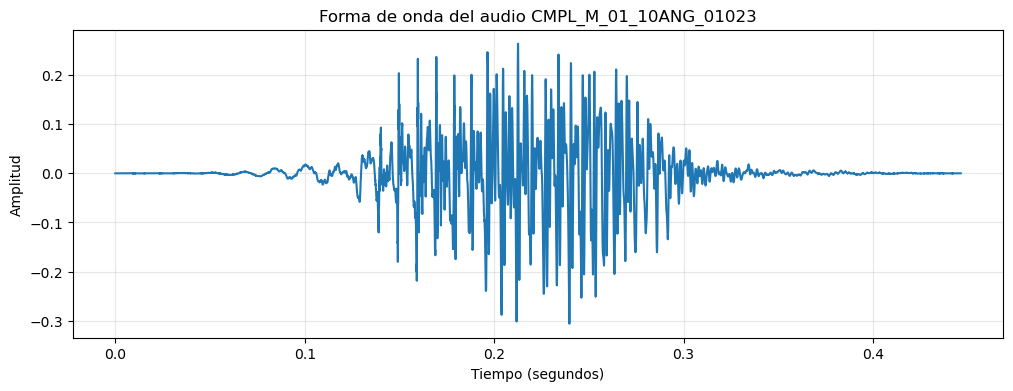

Audio del locutor: M_01
Información del audio
---------------------
Audio ID: CMPL_M_01_10ANG_01117
Speaker ID: M_01
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 8139
Duración: 0.51 segundos


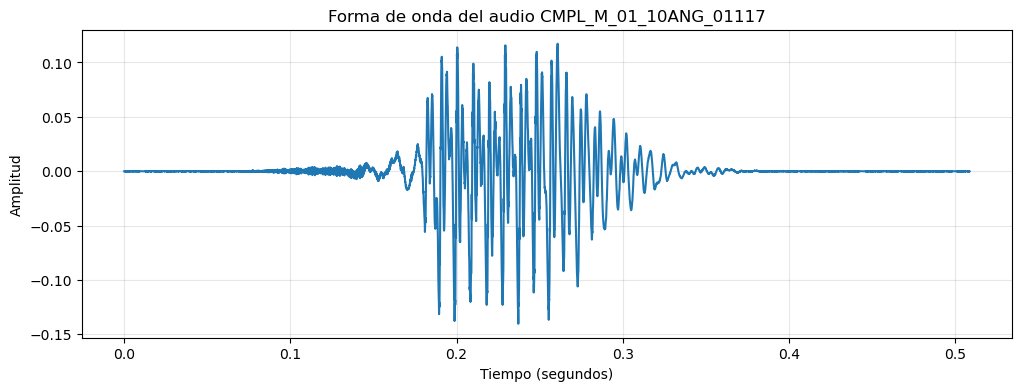

Audio del locutor: M_01
Información del audio
---------------------
Audio ID: CMPL_M_01_04ANG_00591
Speaker ID: M_01
Género: male
Frecuencia de muestreo: 16000 Hz
Número de muestras: 8706
Duración: 0.54 segundos


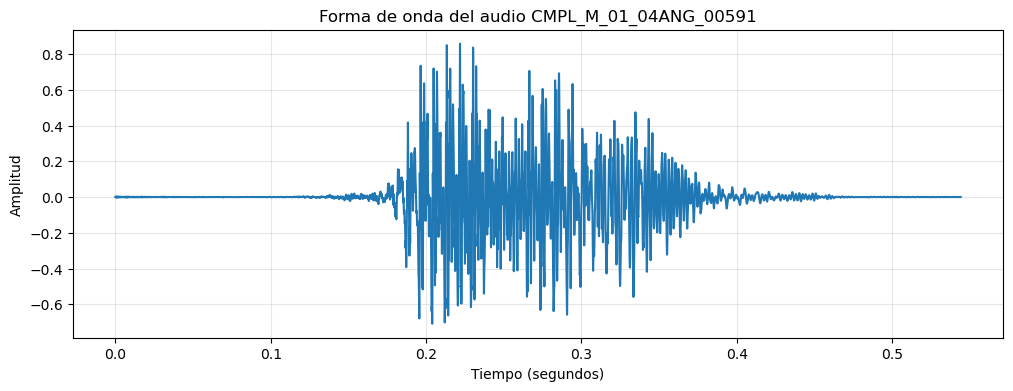

In [43]:
for _, row in audios_mismo_locutor.iterrows():
    print("=" * 80)
    print(f"Audio del locutor: {speaker_ejemplo}")
    inspeccionar_audio(ciempiess_no_decode, row["audio_id"])

### Observaciones cualitativas preliminares

A partir de la revisión de ejemplos de audio, se observaron los siguientes aspectos:

- **Calidad general del audio:** En general los audios se escuchan con una calidad razonable, aunque en la mayoría de ellos se escucha cierto eco.
- **Claridad de la voz:** Las voces se escuchan claras en su mayoría.
- **Presencia de ruido:** No se puede detectar la presencia de ruido considerable.
- **Silencios al inicio o final:** La mayoría de los audio no presenta silencia considerable al inicio o al final.
- **Cortes abruptos:** En la mayoría de los audios si se presentan cortes abruptos.
- **Variabilidad entre audios del mismo locutor:** No existe demasiada variabilidad entre audios del mismo locutos.


# 10. Limpieza y criterios preliminares de filtrado

En esta sección se definen criterios preliminares de limpieza y filtrado para el corpus CIEMPIESS.

Hasta este punto se han analizado características generales del corpus, como duración de los audios, número de grabaciones por locutor, distribución por género y ejemplos individuales de audio. Con base en estos análisis, ahora se propone una primera versión filtrada de los metadatos.

El objetivo de esta sección no es eliminar información de forma definitiva, sino construir un conjunto de datos preliminar que cumpla condiciones mínimas para tareas posteriores de reconocimiento de locutor.


### 10.1 Copia de trabajo del DataFrame

Antes de aplicar filtros, se crea una copia de la tabla original de metadatos. Esto permite conservar `df_meta` como referencia completa del corpus original y trabajar sobre una nueva tabla llamada `df_limpieza`.



In [44]:
df_limpieza = df_meta.copy()

print(f"Número inicial de audios: {len(df_limpieza)}")
print(f"Número inicial de locutores: {df_limpieza['speaker_id'].nunique()}")

Número inicial de audios: 16663
Número inicial de locutores: 87


### 10.2 Revisión de valores faltantes

Los valores faltantes pueden generar problemas en el análisis posterior.

Por ejemplo:

- un audio sin `speaker_id` no puede utilizarse para reconocimiento de locutor,
- un audio sin duración no puede evaluarse bajo criterios de filtrado,
- un audio sin frecuencia de muestreo no permite saber si requiere remuestreo,
- y un audio sin ruta o información de audio puede ser difícil de recuperar.

Por esta razón, se revisa la cantidad de valores faltantes por columna.

In [ ]:
# Verificación de columnas necesarias
columnas_necesarias = [
    "audio_id",
    "speaker_id",
    "gender",
    "sampling_rate",
    "num_samples",
    "duration_sec",
    "audio_path"
]

columnas_existentes = df_limpieza.columns.tolist()

for col in columnas_necesarias:
    if col in columnas_existentes:
        print(f"Columna encontrada: {col}")
    else:
        print(f"Columna faltante: {col}")

Columna encontrada: audio_id
Columna encontrada: speaker_id
Columna encontrada: gender
Columna encontrada: sampling_rate
Columna encontrada: num_samples
Columna encontrada: duration_sec
Columna encontrada: audio_path


In [47]:
# Valores faltantes por columna
valores_faltantes = df_limpieza[columnas_necesarias].isna().sum()

valores_faltantes

audio_id         0
speaker_id       0
gender           0
sampling_rate    0
num_samples      0
duration_sec     0
audio_path       0
dtype: int64

In [48]:
# Filtrado por valores faltantes críticos
columnas_criticas = [
    "audio_id",
    "speaker_id",
    "sampling_rate",
    "duration_sec",
    "num_samples"
]

n_antes = len(df_limpieza)

df_limpieza = df_limpieza.dropna(subset=columnas_criticas).copy()

n_despues = len(df_limpieza)

print(f"Audios antes del filtro: {n_antes}")
print(f"Audios después del filtro: {n_despues}")
print(f"Audios eliminados: {n_antes - n_despues}")
print(f"Porcentaje eliminado: {(n_antes - n_despues) / n_antes * 100:.2f}%")

Audios antes del filtro: 16663
Audios después del filtro: 16663
Audios eliminados: 0
Porcentaje eliminado: 0.00%


### 10.3 Filtro por duración mínima

La duración mínima es uno de los criterios más importantes para reconocimiento de locutor.
Con base en el análisis exploratorio anterior, se usará inicialmente:

$$
\text{duración mínima} = 2 \text{ segundos}
$$

Este valor puede modificarse más adelante dependiendo del impacto sobre la cantidad de audios y locutores disponibles.

In [49]:
duracion_minima = 2.0

n_antes = len(df_limpieza)

df_limpieza = df_limpieza[
    df_limpieza["duration_sec"] >= duracion_minima
].copy()

n_despues = len(df_limpieza)

print(f"Duración mínima considerada: {duracion_minima} segundos")
print(f"Audios antes del filtro: {n_antes}")
print(f"Audios después del filtro: {n_despues}")
print(f"Audios eliminados: {n_antes - n_despues}")
print(f"Porcentaje eliminado: {(n_antes - n_despues) / n_antes * 100:.2f}%")

Duración mínima considerada: 2.0 segundos
Audios antes del filtro: 16663
Audios después del filtro: 13252
Audios eliminados: 3411
Porcentaje eliminado: 20.47%


Después de aplicar filtros a nivel de audio, es necesario revisar cuántos audios conserva cada locutor.
Esto es importante porque un filtro puede conservar una gran cantidad de audios a nivel global, pero dejar a ciertos locutores con muy pocas grabaciones.

Para una tarea de verificación de locutor, se necesita al menos más de una grabación por hablante, aunque en la práctica se recomienda contar con más audios para separar inscripción, prueba y evaluación.

In [50]:
audios_por_locutor_limpieza = (
    df_limpieza
    .groupby("speaker_id")
    .agg(
        n_audios=("audio_id", "count"),
        gender=("gender", "first"),
        duracion_total_seg=("duration_sec", "sum")
    )
    .reset_index()
)

audios_por_locutor_limpieza["duracion_total_min"] = (
    audios_por_locutor_limpieza["duracion_total_seg"] / 60
)

audios_por_locutor_limpieza.sort_values("n_audios").head(10)

,speaker_id,n_audios,gender,duracion_total_seg,duracion_total_min
31,F_32,12,female,31.430688,0.523845
32,F_33,14,female,46.911687,0.781861
33,F_34,15,female,46.587250,0.776454
86,M_53,24,male,108.271125,1.804519
84,M_51,25,male,80.214250,1.336904
85,M_52,26,male,112.394312,1.873239
24,F_25,26,female,79.823500,1.330392
30,F_31,27,female,134.679563,2.244659
83,M_50,28,male,154.285875,2.571431
71,M_38,28,male,80.375938,1.339599


### 10.4 Filtro por número mínimo de audios por locutor

Además de filtrar audios individuales, se define un criterio mínimo a nivel de locutor.

Para speaker verification, un locutor con solo un audio no permite construir pares positivos. Sin embargo, para un protocolo más estable se recomienda exigir más de dos audios.
En esta etapa se propone de forma preliminar conservar locutores con al menos:

$$
5 \text{ audios}
$$

Este criterio puede modificarse posteriormente dependiendo de cuántos locutores y audios se conserven.

In [51]:
min_audios_por_locutor = 5

# Identificar locutores que cumplen el criterio
locutores_validos = (
    audios_por_locutor_limpieza[
        audios_por_locutor_limpieza["n_audios"] >= min_audios_por_locutor
    ]["speaker_id"]
)

n_antes = len(df_limpieza)
n_locutores_antes = df_limpieza["speaker_id"].nunique()

df_limpieza = df_limpieza[
    df_limpieza["speaker_id"].isin(locutores_validos)
].copy()

n_despues = len(df_limpieza)
n_locutores_despues = df_limpieza["speaker_id"].nunique()

print(f"Mínimo de audios por locutor: {min_audios_por_locutor}")
print(f"Audios antes del filtro: {n_antes}")
print(f"Audios después del filtro: {n_despues}")
print(f"Audios eliminados: {n_antes - n_despues}")
print()
print(f"Locutores antes del filtro: {n_locutores_antes}")
print(f"Locutores después del filtro: {n_locutores_despues}")
print(f"Locutores eliminados: {n_locutores_antes - n_locutores_despues}")

Mínimo de audios por locutor: 5
Audios antes del filtro: 13252
Audios después del filtro: 13252
Audios eliminados: 0

Locutores antes del filtro: 87
Locutores después del filtro: 87
Locutores eliminados: 0


### 10.5 Comparación entre corpus original y corpus limpio

Una vez aplicados los filtros preliminares, se compara el corpus original con la versión limpia.



In [52]:
comparacion_limpieza = pd.DataFrame({
    "Conjunto": ["Original", "Limpio preliminar"],
    "Número de audios": [
        len(df_meta),
        len(df_limpieza)
    ],
    "Número de locutores": [
        df_meta["speaker_id"].nunique(),
        df_limpieza["speaker_id"].nunique()
    ],
    "Duración total horas": [
        df_meta["duration_sec"].sum() / 3600,
        df_limpieza["duration_sec"].sum() / 3600
    ],
    "Duración promedio audio seg": [
        df_meta["duration_sec"].mean(),
        df_limpieza["duration_sec"].mean()
    ],
    "Duración mediana audio seg": [
        df_meta["duration_sec"].median(),
        df_limpieza["duration_sec"].median()
    ]
})

comparacion_limpieza

,Conjunto,Número de audios,Número de locutores,Duración total horas,Duración promedio audio seg,Duración mediana audio seg
0,Original,16663,87,18.424002,3.980460,3.301000
1,Limpio preliminar,13252,87,17.030359,4.626418,3.842938


### 10.6 Comparación por género antes y después del filtrado

Además de revisar el impacto global, es importante analizar si el filtrado afecta de forma diferente a cada género.



In [53]:
genero_original = (
    df_meta
    .groupby("gender")
    .agg(
        n_audios_original=("audio_id", "count"),
        n_locutores_original=("speaker_id", "nunique"),
        duracion_original_horas=("duration_sec", lambda x: x.sum() / 3600)
    )
    .reset_index()
)

genero_limpio = (
    df_limpieza
    .groupby("gender")
    .agg(
        n_audios_limpio=("audio_id", "count"),
        n_locutores_limpio=("speaker_id", "nunique"),
        duracion_limpia_horas=("duration_sec", lambda x: x.sum() / 3600)
    )
    .reset_index()
)

comparacion_genero_limpieza = genero_original.merge(
    genero_limpio,
    on="gender",
    how="left"
)

comparacion_genero_limpieza["n_audios_limpio"] = (
    comparacion_genero_limpieza["n_audios_limpio"].fillna(0).astype(int)
)

comparacion_genero_limpieza["n_locutores_limpio"] = (
    comparacion_genero_limpieza["n_locutores_limpio"].fillna(0).astype(int)
)

comparacion_genero_limpieza["duracion_limpia_horas"] = (
    comparacion_genero_limpieza["duracion_limpia_horas"].fillna(0)
)

comparacion_genero_limpieza["audios_eliminados"] = (
    comparacion_genero_limpieza["n_audios_original"]
    - comparacion_genero_limpieza["n_audios_limpio"]
)

comparacion_genero_limpieza["porcentaje_audios_eliminados"] = (
    comparacion_genero_limpieza["audios_eliminados"]
    / comparacion_genero_limpieza["n_audios_original"] * 100
)

comparacion_genero_limpieza

,gender,n_audios_original,n_locutores_original,duracion_original_horas,n_audios_limpio,n_locutores_limpio,duracion_limpia_horas,audios_eliminados,porcentaje_audios_eliminados
0,female,4142,34,5.739909,3642,34,5.538621,500,12.071463
1,male,12521,53,12.684093,9610,53,11.491739,2911,23.248942


### 10.6 Registro de criterios aplicados

Los criterios preliminares aplicados en esta sección fueron:

| Criterio | Valor utilizado | Justificación |
|---|---:|---|
| Valores faltantes críticos | Se eliminaron registros incompletos | Evitar errores en etapas posteriores |
| Duración mínima | 2 segundos | Evitar audios con poca información acústica |
| Mínimo de audios por locutor | 5 audios | Permitir formación básica de pares positivos |

Estos criterios son preliminares. En etapas posteriores pueden modificarse dependiendo del diseño del protocolo experimental.

# 11. Viabilidad para speaker recognition

En esta sección se evalúa si el corpus CIEMPIESS Light es viable para tareas de reconocimiento de locutor.

Hasta este punto se han analizado aspectos generales del corpus, tales como:

- número total de audios,
- número total de locutores,
- duración de las grabaciones,
- distribución por locutor,
- distribución por género,
- ejemplos cualitativos de audio,
- y criterios preliminares de limpieza.

Ahora se utilizará esta información para discutir si el corpus puede emplearse en tareas de **speaker recognition**, especialmente en **speaker verification**, que es una formulación cercana al contexto forense.

El objetivo de esta sección no es entrenar modelos todavía, sino justificar técnicamente si el corpus tiene las condiciones mínimas para continuar hacia la implementación de modelos como **x-vectors** y **ECAPA-TDNN**.

### 11.1 Identificación y verificación de locutor

En reconocimiento de locutor existen dos formulaciones principales:

#### Identificación de locutor

En la **identificación de locutor**, el sistema recibe un audio de prueba y debe decidir a qué locutor pertenece dentro de un conjunto conocido de hablantes.

La pregunta principal es:

> ¿Quién está hablando?

Esta tarea suele formularse como un problema de clasificación multiclase.

#### Verificación de locutor

En la **verificación de locutor**, el sistema recibe dos audios, o un audio de referencia y un audio de prueba, y debe decidir si corresponden al mismo locutor.

La pregunta principal es:

> ¿Estos dos audios pertenecen a la misma persona?


En este proyecto, la comparación entre **x-vectors** y **ECAPA-TDNN** se orientará principalmente hacia **speaker verification**, ya que permite evaluar embeddings mediante métricas como EER, ROC, DET, FAR y FRR.

### 11.2 Criterios de viabilidad

Para decidir si el corpus es viable para continuar con la implementación, se consideran los siguientes criterios:

| Criterio | Evaluación esperada |
|---|---|
| Existencia de `speaker_id` | Necesario para construir etiquetas de locutor. |
| Múltiples locutores | Necesario para formar pares negativos. |
| Múltiples audios por locutor | Necesario para formar pares positivos. |
| Duración suficiente | Necesaria para extraer embeddings razonables. |
| Frecuencia de muestreo homogénea | Facilita el uso de modelos preentrenados. |
| Posibilidad de formar pares | Necesaria para speaker verification. |
| Documentación de limitaciones | Necesaria para interpretación forense. |

Si estos criterios se cumplen de forma razonable, el corpus puede utilizarse para una primera implementación del sistema.

A continuación se construye una tabla que resume si el corpus limpio cumple algunos criterios básicos de viabilidad.

Esta tabla no reemplaza la interpretación técnica, pero ayuda a documentar de forma clara el estado del corpus.

In [ ]:
# ============================================================
# Disponibilidad por locutor después de limpieza
# ============================================================

resumen_locutor_limpio = (
    df_limpieza
    .groupby("speaker_id")
    .agg(
        gender=("gender", "first"),
        n_audios=("audio_id", "count"),
        duracion_total_seg=("duration_sec", "sum"),
        duracion_promedio_seg=("duration_sec", "mean"),
        duracion_mediana_seg=("duration_sec", "median")
    )
    .reset_index()
)

resumen_locutor_limpio["duracion_total_min"] = (
    resumen_locutor_limpio["duracion_total_seg"] / 60
)

resumen_locutor_limpio = resumen_locutor_limpio.sort_values(
    "n_audios",
    ascending=False
)

resumen_locutor_limpio.head()

,speaker_id,gender,n_audios,duracion_total_seg,duracion_promedio_seg,duracion_mediana_seg,duracion_total_min
34,M_01,male,1197,4124.003625,3.445283,3.039813,68.733394
0,F_01,female,791,3702.919563,4.681314,4.014000,61.715326
36,M_03,male,783,5359.160063,6.844393,7.072563,89.319334
35,M_02,male,572,1746.784312,3.053819,2.871437,29.113072
37,M_04,male,447,1665.937625,3.726930,3.559563,27.765627


In [60]:
# ============================================================
# Pares positivos posibles después de limpieza
# ============================================================

resumen_locutor_limpio["pares_positivos_posibles"] = (
    resumen_locutor_limpio["n_audios"]
    * (resumen_locutor_limpio["n_audios"] - 1)
    // 2
)

total_pares_positivos_limpio = (
    resumen_locutor_limpio["pares_positivos_posibles"].sum()
)

print(f"Total potencial de pares positivos después de limpieza: {total_pares_positivos_limpio:,}")

resumen_locutor_limpio[
    ["speaker_id", "gender", "n_audios", "pares_positivos_posibles"]
].head(10)

Total potencial de pares positivos después de limpieza: 2,519,225


,speaker_id,gender,n_audios,pares_positivos_posibles
34,M_01,male,1197,715806
0,F_01,female,791,312445
36,M_03,male,783,306153
35,M_02,male,572,163306
37,M_04,male,447,99681
1,F_02,female,437,95266
40,M_07,male,414,85491
41,M_08,male,383,73153
42,M_09,male,345,59340
2,F_03,female,343,58653


In [61]:
# ============================================================
# Pares negativos posibles después de limpieza
# ============================================================

n_audios_limpios = len(df_limpieza)

total_pares_posibles = n_audios_limpios * (n_audios_limpios - 1) // 2

total_pares_negativos_limpio = (
    total_pares_posibles - total_pares_positivos_limpio
)

print(f"Total de audios limpios: {n_audios_limpios:,}")
print(f"Total de pares posibles: {total_pares_posibles:,}")
print(f"Total potencial de pares positivos: {total_pares_positivos_limpio:,}")
print(f"Total potencial de pares negativos: {total_pares_negativos_limpio:,}")

Total de audios limpios: 13,252
Total de pares posibles: 87,801,126
Total potencial de pares positivos: 2,519,225
Total potencial de pares negativos: 85,281,901


In [63]:
# ============================================================
# Evaluación automática de criterios básicos
# ============================================================

criterios_viabilidad = pd.DataFrame({
    "Criterio": [
        "Tiene audios disponibles",
        "Tiene identificadores de locutor",
        "Tiene más de un locutor",
        "Todos los locutores tienen al menos 2 audios",
        "Todos los locutores tienen al menos 5 audios",
        "Frecuencia de muestreo homogénea",
        "Duración mínima igual o mayor a 2 segundos",
        "Permite formar pares positivos",
        "Permite formar pares negativos"
    ],
    "Se cumple": [
        len(df_limpieza) > 0,
        df_limpieza["speaker_id"].notna().all(),
        df_limpieza["speaker_id"].nunique() > 1,
        resumen_locutor_limpio["n_audios"].min() >= 2,
        resumen_locutor_limpio["n_audios"].min() >= 5,
        df_limpieza["sampling_rate"].nunique() == 1,
        df_limpieza["duration_sec"].min() >= 2,
        total_pares_positivos_limpio > 0,
        total_pares_negativos_limpio > 0
    ]
})

criterios_viabilidad

,Criterio,Se cumple
0,Tiene audios disponibles,True
1,Tiene identificadores de locutor,True
2,Tiene más de un locutor,True
3,Todos los locutores tienen al menos 2 audios,True
4,Todos los locutores tienen al menos 5 audios,True
5,Frecuencia de muestreo homogénea,True
6,Duración mínima igual o mayor a 2 segundos,True
7,Permite formar pares positivos,True
8,Permite formar pares negativos,True


## Conclusión de viabilidad

Con base en el análisis exploratorio realizado, el corpus CIEMPIESS Light presenta características que permiten utilizarlo en una primera implementación de reconocimiento de locutor.

El corpus cuenta con identificadores de locutor, múltiples audios por hablante, duración medible de las grabaciones y una frecuencia de muestreo compatible con modelos de procesamiento de voz. Estas condiciones permiten construir pares positivos y negativos para una tarea de **speaker verification**.

Después de aplicar criterios preliminares de limpieza, el conjunto resultante conserva audios y locutores suficientes para continuar con el diseño de un protocolo experimental. En particular, la existencia de múltiples grabaciones por locutor permite plantear una comparación entre embeddings obtenidos con **x-vectors** y **ECAPA-TDNN**.

Sin embargo, CIEMPIESS Light debe considerarse un corpus experimental para este proyecto y no una base forense estricta. Sus resultados deberán interpretarse considerando que el corpus fue diseñado originalmente para tecnologías del habla y no específicamente para evaluación forense.

Por lo tanto, se concluye que CIEMPIESS Light es viable para una primera etapa de implementación y comparación de modelos de reconocimiento de locutor, siempre que se documenten sus limitaciones y se diseñe cuidadosamente el protocolo experimental.

## Guardado de metadatos limpios

Después de aplicar los criterios preliminares de limpieza, se guarda la tabla resultante en un archivo `.csv`.

Este archivo no contiene los audios, sino únicamente los metadatos filtrados. Guardarlo permite reutilizar la selección preliminar en etapas posteriores sin repetir todo el proceso de limpieza.

In [64]:
df_limpieza.to_csv("metadata_ciempiess_light_limpio_preliminar.csv", index=False)

print("Archivo guardado: metadata_ciempiess_light_limpio_preliminar.csv")

Archivo guardado: metadata_ciempiess_light_limpio_preliminar.csv
